# Wasserstein K-Means

## Market regime detection for multiple stocks

In [3]:
import sys

sys.path.append("..")

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import trange
from scipy.stats import kstest, levene

In [37]:
%load_ext autoreload
%autoreload 2

from market_regime_detection.data import load_yf_data, compute_log_returns

from market_regime_detection.wasserstein_multivariate import (
    split_array_into_windows,
    sliced_wasserstein_distance,
    wasserstein_k_means_multivariate,
    get_corrected_assignments,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading data

In [14]:
TICKERS = ["MSFT", "AAPL", "CSX", "LMT"]

In [15]:
date_from = "2016-01-01"
date_to = "2026-01-01"

In [16]:
market_data = load_yf_data(tickers=TICKERS, date_from=date_from, date_to=date_to)

[*********************100%***********************]  4 of 4 completed


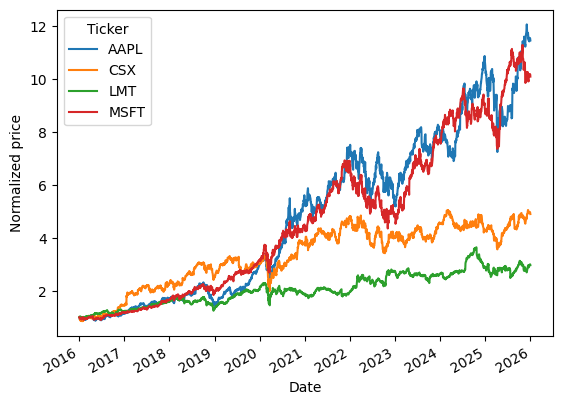

In [17]:
market_data.div(market_data.iloc[0, :]).plot()
plt.ylabel("Normalized price")
plt.xlabel("Date")
plt.show()

Exactly 252 trading days on average

In [18]:
market_data.index.year.value_counts()

Date
2020    253
2016    252
2021    252
2019    252
2024    252
2017    251
2018    251
2022    251
2023    250
2025    250
Name: count, dtype: int64

Compute log-returns

In [19]:
market_returns = market_data.apply(compute_log_returns, axis=0)
market_returns = market_returns.set_index(market_data.index[1:].floor("d"))

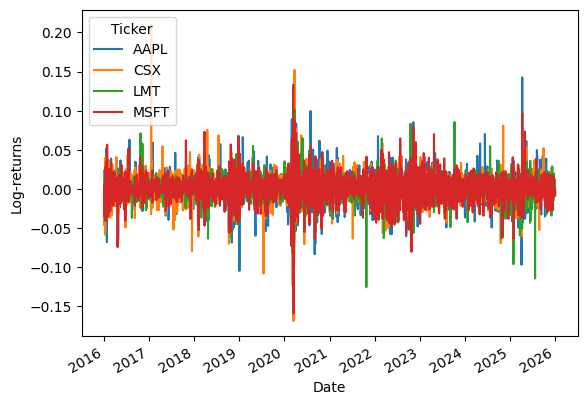

In [20]:
market_returns.plot()
plt.ylabel("Log-returns")
plt.xlabel("Date")
plt.show()

## Clusterization

In [23]:
WINDOW_LENGTH_DAYS = 40  # ~ 2 months

In [30]:
data_for_clustering = split_array_into_windows(
    market_returns=market_returns.to_numpy(),
    window_shape=(WINDOW_LENGTH_DAYS, market_returns.shape[1]),
)

In [35]:
data_for_clustering = data_for_clustering.squeeze(1)

- 2 clusters - bull and bear market
- 3 clusters - bull / neutral / stress
- 4+ clusters - volatility clustering / finer market regimes

In [45]:
assignments, _, _ = wasserstein_k_means_multivariate(
    measures=data_for_clustering, n_clusters=2, max_iter=100
)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [31:04<00:00, 18.64s/it]


In [49]:
corrected_assignments = get_corrected_assignments(
    assignments=assignments, window_shape=WINDOW_LENGTH_DAYS
)

## Visualization

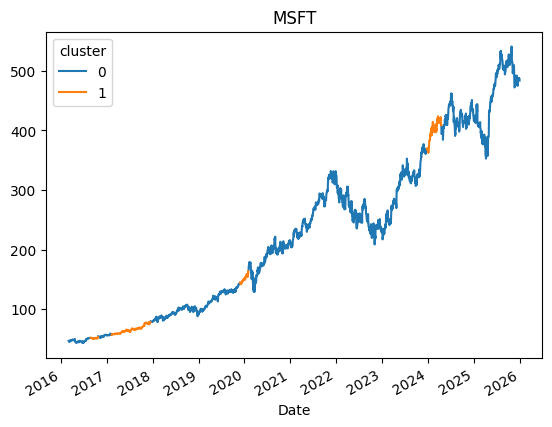

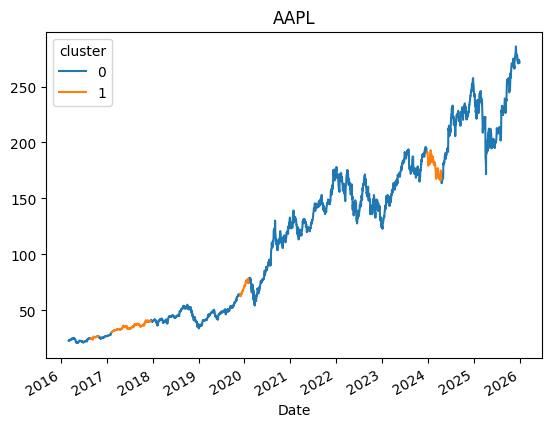

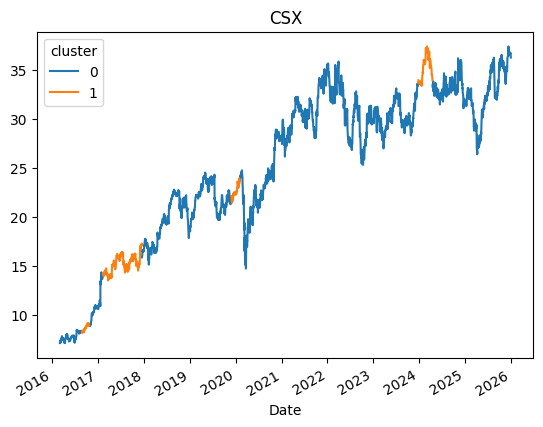

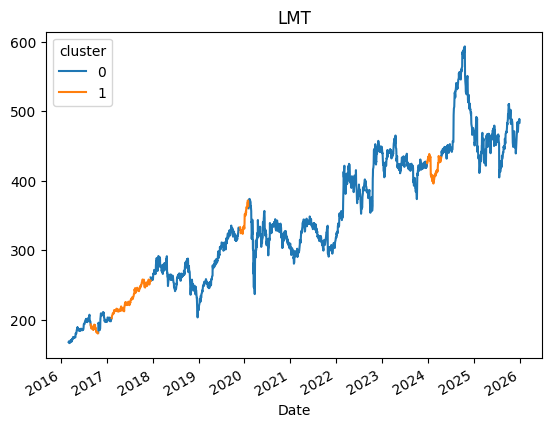

In [53]:
for ticker in TICKERS:

    (
        market_data.iloc[WINDOW_LENGTH_DAYS:, :][[ticker]]
        .assign(cluster=corrected_assignments)
        .reset_index()
        .pivot(index="Date", columns="cluster", values=ticker)
        .plot()
    )

    plt.title(ticker)
    plt.show()

It seems that model caught the:

1. 1 year of Trump first term (2017)
2. Pre-pandemic period (2019H2)
3. Late 2023 market rally (2023H2)

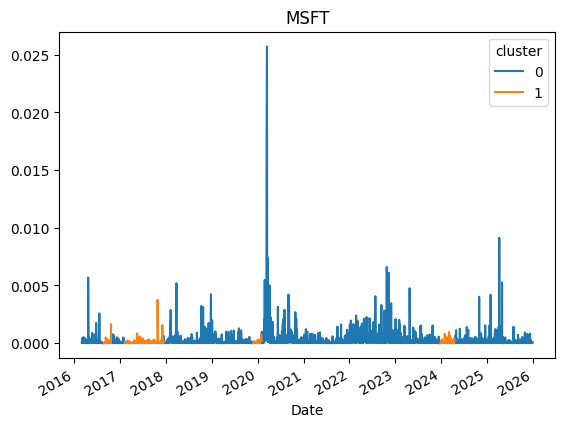

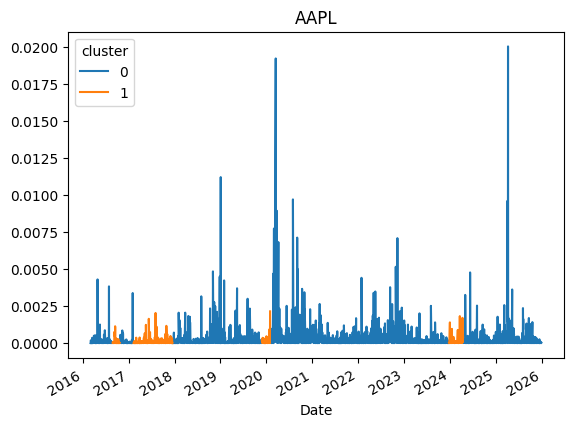

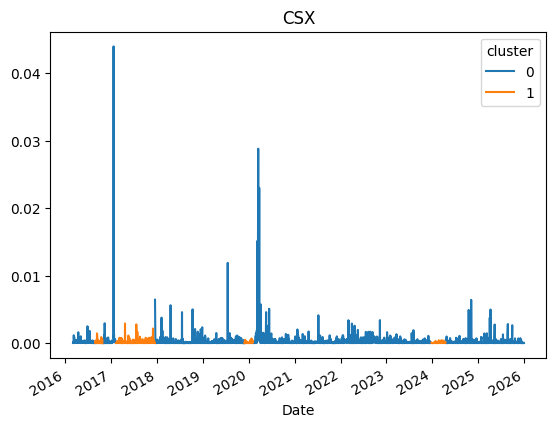

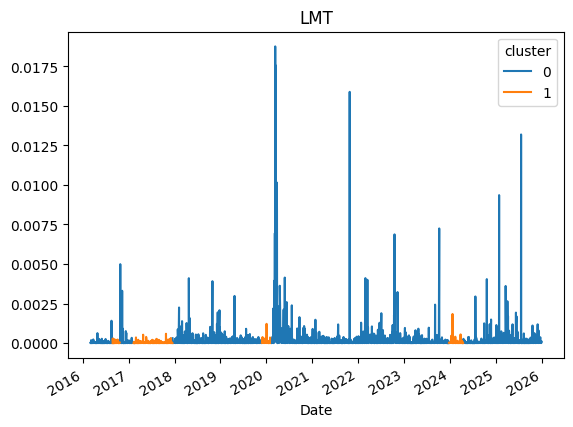

In [55]:
for ticker in TICKERS:

    (
        market_returns.iloc[WINDOW_LENGTH_DAYS - 1 :, :][[ticker]]
        .apply(lambda x: (x - np.mean(x)) ** 2)
        .assign(cluster=corrected_assignments)
        .reset_index()
        .pivot(index="Date", columns="cluster", values=ticker)
        .plot()
    )

    plt.title(ticker)
    plt.show()